In [ ]:
# Integrated Google Colab Code for Rover Path Planning and Scientific Spot Identification
# Combines Hunger Games Optimization with RRT for path planning and
# scientific feature classification/clustering for identifying spots of interest.
# Uses direct file paths for terrain PNG, .hdr, and .qub inputs, and includes a new PNG output
# with the optimized route and scientific spots marked.
# Optimized to prevent Colab session crashes and fixed TypeError in RRT.

# Step 1: Install required libraries
!pip install opencv-python-headless numpy matplotlib pandas geopandas shapely scikit-learn spectral

# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from google.colab import files
from google.colab import drive
import random
import heapq
import os
from sklearn.cluster import KMeans
from spectral.io import envi  # For reading .hdr and .qub files

# Step 2: Mount Google Drive for .qub file access
print("Mounting Google Drive...")
try:
    drive.mount('/content/drive')
except Exception as e:
    print(f"Error mounting Google Drive: {e}")
    raise

# Step 3: Create output directory
output_dir = "/content/results/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Step 4: Specify file paths for inputs
img_filename = "/content/image.png"  # Path to terrain PNG
hdr_filename = "/content/hyperhdr.hdr"  # Path to hyperspectral .hdr file
qub_filename = "/content/drive/MyDrive/IIRS DATA TEST/ch2_iir_nci_20221227T1144179457_d_img_d32.qub"  # Path to hyperspectral .qub file

# Verify file existence
for fname in [img_filename, hdr_filename, qub_filename]:
    if not os.path.exists(fname):
        raise FileNotFoundError(f"File not found: {fname}")
print("All input files found.")

# Step 5: Preprocess terrain image
print("Loading terrain image...")
raster_img = cv2.imread(img_filename, cv2.IMREAD_GRAYSCALE)
if raster_img is None:
    raise FileNotFoundError(f"Could not load terrain image: {img_filename}")
height, width = raster_img.shape
print(f"Terrain image dimensions: {height}x{width}")

blurred = cv2.GaussianBlur(raster_img, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# Detect contours as obstacles
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
raster_colored = cv2.cvtColor(raster_img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(raster_colored, contours, -1, (0, 255, 0), 1)

# Create obstacle mask
obstacle_mask = np.zeros_like(raster_img, dtype=np.uint8)
cv2.drawContours(obstacle_mask, contours, -1, (255), thickness=cv2.FILLED)

# Define start and goal positions
start = (height - 10, width // 2)  # Start near bottom center
end = (10, width // 2)  # Goal near top center

# Step 6: Read and downsample hyperspectral cube data
print("Loading hyperspectral cube...")
try:
    cube = envi.open(hdr_filename, qub_filename).load()
    cube = np.array(cube)  # Shape: height, width, bands
    print(f"Original cube shape: {cube.shape}")

    # Downsample to match terrain image dimensions
    scale_factor = min(height / cube.shape[0], width / cube.shape[1])
    if scale_factor < 1:
        cube = cv2.resize(cube, (width, height))
        print(f"Downsampled cube shape: {cube.shape}")
except Exception as e:
    print(f"Error loading hyperspectral data: {e}")
    raise

# Step 7: Process hyperspectral cube for scientific feature classification
num_bands = cube.shape[2]
try:
    # Attempt to get wavelengths from .hdr metadata
    wavelengths = envi.open(hdr_filename).metadata.get('wavelength', np.linspace(0.8, 2.5, num_bands))
    wavelengths = np.array(wavelengths, dtype=float)
except:
    wavelengths = np.linspace(0.8, 2.5, num_bands)
print(f"Assigned wavelengths. First 10: {wavelengths[:10]}")

# Sample a subset of pixels for clustering to reduce memory usage
print("Sampling pixels for clustering...")
max_samples = 10000  # Maximum number of pixels to cluster
pixels = cube.reshape(-1, num_bands)
if pixels.shape[0] > max_samples:
    indices = np.random.choice(pixels.shape[0], max_samples, replace=False)
    X = pixels[indices]
else:
    X = pixels
print(f"Sampled data shape: {X.shape}")

# Perform K-means clustering
n_clusters = 4  # Water, Minerals, Thermal, Ices
print("Running K-means clustering...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_sample = kmeans.fit_predict(X)
del X  # Free memory

# Predict labels for all pixels
print("Predicting labels for all pixels...")
labels = kmeans.predict(pixels)
del pixels  # Free memory
label_map = labels.reshape(height, width)
del labels  # Free memory
print("Clustering completed.")

# Create high-density cluster dataframe
print("Creating cluster dataframe...")
high_density_df = pd.DataFrame({
    'x': np.repeat(np.arange(width), height),
    'y': np.tile(np.arange(height), width),
    'label': label_map.flatten()
})

# Filter high-density clusters
high_density_df = high_density_df[high_density_df['label'].isin([1, 2, 3, 4])]

# Compute centroids for each cluster
centroid_coords = []
for label in [1, 2, 3, 4]:
    subset = high_density_df[high_density_df['label'] == label]
    if not subset.empty:
        centroid = [subset['x'].mean(), subset['y'].mean(), label, label]
        centroid_coords.append(centroid)
centroid_df = pd.DataFrame(centroid_coords, columns=["x", "y", "label", "cluster"])
print("Centroid class counts:")
print(centroid_df['label'].value_counts())

# Step 8: Visualize label map
print("Generating scientific feature map...")
cmap = mcolors.ListedColormap(['black', 'blue', 'red', 'orange', 'cyan'])
labels_legend = ['Background', 'Water', 'Minerals', 'Thermal', 'Ices']
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(label_map, cmap=cmap, interpolation='nearest')
cbar = plt.colorbar(im, ticks=range(5), ax=ax)
cbar.ax.set_yticklabels(labels_legend)
plt.title("Scientific Feature Classification Map")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "scientific_feature_map.png"))
plt.close()

# Step 9: Visualize clusters with centroids
print("Generating cluster visualization...")
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue', 'red', 'orange', 'cyan']
labels_map = {1: 'Water', 2: 'Minerals', 3: 'Thermal', 4: 'Ices'}
for class_id, color in zip([1, 2, 3, 4], colors):
    subset = high_density_df[high_density_df['label'] == class_id]
    if not subset.empty:
        ax.scatter(subset['x'], subset['y'], s=10, label=labels_map[class_id], alpha=0.6, c=color)
ax.scatter(centroid_df['x'], centroid_df['y'], marker='x', c='black', label='Centroids')
ax.legend()
ax.set_title("High-Density Scientific Clusters with Centroids")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
plt.tight_layout()
cluster_png = os.path.join(output_dir, "high_density_clusters.png")
plt.savefig(cluster_png)
print(f"Cluster visualization saved to: {cluster_png}")
plt.close()

# Step 10: Export for GIS use
print("Exporting GIS files...")
wgs_crs = "EPSG:4326"
lunar_proj = "+proj=longlat +a=1737400 +b=1737400 +no_defs"
cluster_shapefile = os.path.join(output_dir, "high_density_clusters.shp")
geometry_clusters = [Point(xy) for xy in zip(high_density_df['x'], high_density_df['y'])]
gdf_clusters = gpd.GeoDataFrame(high_density_df, geometry=geometry_clusters)
try:
    gdf_clusters.set_crs(lunar_proj, inplace=True)
except:
    print("Falling back to WGS84")
    gdf_clusters.set_crs(wgs_crs, inplace=True)
gdf_clusters.to_file(cluster_shapefile)
print(f"Shapefile exported: {cluster_shapefile}")

centroid_geojson = os.path.join(output_dir, "cluster_centroids.geojson")
geometry_centroids = [Point(xy) for xy in zip(centroid_df['x'], centroid_df['y'])]
gdf_centroids = gpd.GeoDataFrame(centroid_df, geometry=geometry_centroids)
try:
    gdf_centroids.set_crs(lunar_proj, inplace=True)
except:
    print("Falling back to WGS84")
    gdf_centroids.set_crs(wgs_crs, inplace=True)
gdf_centroids.to_file(centroid_geojson, driver='GeoJSON')
print(f"GeoJSON exported: {centroid_geojson}")

# Step 11: Define Node class for RRT
class Node:
    def __init__(self, pos, parent=None):
        self.pos = pos
        self.parent = parent

# Step 12: Utility functions for RRT
def dist(a, b):
    """Calculate Euclidean distance between two points."""
    return np.linalg.norm(np.array(a) - np.array(b))

def collision_free(pos):
    """Check if a position is collision-free."""
    x, y = pos
    return 0 <= x < height and 0 <= y < width and obstacle_mask[int(x), int(y)] == 0

def hgs_sample(goal, best_pos, W_adaptive):
    """Hunger Games Optimization influenced sampling."""
    if random.random() < W_adaptive:
        direction = np.array(goal) - np.array(best_pos)
    else:
        direction = np.random.uniform(-1, 1, size=2)
    direction = direction / np.linalg.norm(direction) if np.linalg.norm(direction) > 0 else direction
    sample_point = np.array(best_pos) + direction * random.randint(10, 30)
    sample_point = np.clip(sample_point, [0, 0], [height-1, width-1])
    return tuple(sample_point.astype(int))

# Step 13: RRT + Hunger Games Search algorithm with scientific spot integration
def hgs_rrt(start, end, iterations=2000, step_size=5):
    """RRT algorithm with HGS, biased towards scientific centroids."""
    tree = [Node(start)]
    best_node = tree[0]
    best_dist = float('inf')

    print("Running RRT+HGS...")
    for i in range(iterations):
        W_adaptive = i / iterations
        rand_point = hgs_sample(end, best_node.pos, W_adaptive)
        nearest = min(tree, key=lambda node: dist(node.pos, rand_point))
        direction = np.array(rand_point) - np.array(nearest.pos)
        direction = direction / np.linalg.norm(direction) if np.linalg.norm(direction) > 0 else direction
        new_pos = tuple((np.array(nearest.pos) + direction * step_size).astype(int))

        if collision_free(new_pos):
            new_node = Node(new_pos, nearest)
            tree.append(new_node)

            # Update best node if closer to goal or near a scientific centroid
            centroid_dist = 0
            if not centroid_df.empty:
                distances = [dist(new_pos, (c['y'], c['x'])) for _, c in centroid_df.iterrows()]
                centroid_dist = min(distances) * 0.1
            current_dist = dist(new_pos, end) + centroid_dist
            if current_dist < best_dist:
                best_node = new_node
                best_dist = current_dist

            # Check if close to goal
            if dist(new_pos, end) < 10:
                print("Goal reached!")
                return new_node

    print("RRT completed.")
    return best_node

# Step 14: Execute RRT+HGS with scientific spot integration
final_node = hgs_rrt(start, end, iterations=2000, step_size=5)

# Step 15: Extract path and create new PNG with route and scientific spots
print("Generating path and new PNG output...")
path_coords = []
route_image = raster_colored.copy()  # Create a copy for the new PNG output
if final_node:
    while final_node:
        path_coords.append(final_node.pos)
        final_node = final_node.parent

    # Draw path on the new route image
    for coord in path_coords:
        y, x = coord
        cv2.circle(route_image, (x, y), 2, (0, 0, 255), -1)

    # Draw scientific centroids on the new route image
    for _, row in centroid_df.iterrows():
        x, y = int(row['x']), int(row['y'])
        cv2.circle(route_image, (x, y), 5, (255, 0, 0), -1)

# Save the new PNG output with route and scientific spots
route_output_filename = "optimized_route_with_spots.png"
cv2.imwrite(os.path.join(output_dir, route_output_filename), route_image)
print(f"New route PNG saved to: {os.path.join(output_dir, route_output_filename)}")

# Step 16: Visualize path on original image for matplotlib output
for coord in path_coords:
    y, x = coord
    cv2.circle(raster_colored, (x, y), 2, (0, 0, 255), -1)

# Draw scientific centroids on original image
for _, row in centroid_df.iterrows():
    x, y = int(row['x']), int(row['y'])
    cv2.circle(raster_colored, (x, y), 5, (255, 0, 0), -1)

# Step 17: Display results with matplotlib (existing output)
print("Generating matplotlib visualization...")
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(raster_colored, cv2.COLOR_BGR2RGB))
plt.scatter(centroid_df['x'], centroid_df['y'], c='blue', marker='x', s=100, label='Scientific Centroids')
plt.plot([x for _, x in path_coords], [y for y, _ in path_coords], 'r-', label='Rover Path')
plt.scatter([start[1]], [start[0]], c='green', marker='o', s=100, label='Start')
plt.scatter([end[1]], [end[0]], c='yellow', marker='o', s=100, label='Goal')
plt.legend()
plt.axis("off")
plt.title("Optimized Rover Path with Scientific Spots")
plt.savefig(os.path.join(output_dir, "optimized_path_with_spots.png"))
plt.close()

# Step 18: Save and download outputs
print("Saving and downloading outputs...")
cv2.imwrite(os.path.join(output_dir, "optimized_path_with_spots.png"), raster_colored)
files.download(os.path.join(output_dir, "optimized_path_with_spots.png"))
files.download(os.path.join(output_dir, route_output_filename))
files.download(cluster_shapefile)
files.download(centroid_geojson)
print("Execution completed.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All input files found.
Loading terrain image...
Terrain image dimensions: 11826x175
Loading hyperspectral cube...
Original cube shape: (16895, 250, 256)
Downsampled cube shape: (11826, 175, 256)
Assigned wavelengths. First 10: [0.8        0.80666667 0.81333333 0.82       0.82666667 0.83333333
 0.84       0.84666667 0.85333333 0.86      ]
Sampling pixels for clustering...
Sampled data shape: (10000, 256)
Running K-means clustering...
Predicting labels for all pixels...
Clustering completed.
Creating cluster dataframe...
Centroid class counts:
label
1    1
2    1
3    1
Name: count, dtype: int64
Generating scientific feature map...
Generating cluster visualization...


<ipython-input-2-01ff20098ded>:177: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
<ipython-input-2-01ff20098ded>:179: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(cluster_png)


Cluster visualization saved to: /content/results/high_density_clusters.png
Exporting GIS files...
Shapefile exported: /content/results/high_density_clusters.shp
GeoJSON exported: /content/results/cluster_centroids.geojson
Running RRT+HGS...
RRT completed.
Generating path and new PNG output...
New route PNG saved to: /content/results/optimized_route_with_spots.png
Generating matplotlib visualization...
Saving and downloading outputs...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Execution completed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#MORE ADVANCED INTEGRATIONS


In [ ]:
# Google Colab Code for Rover Path Planning with Scientific Spot Proximity
# Combines Hunger Games Optimization with RRT for a 100-meter path that starts and ends at specified points,
# prioritizes proximity to named scientific spots, and ensures safe navigation around craters and boulders.
# Optimized to prevent session crashes with downsampling and memory management.

# Step 1: Install required libraries
!pip install opencv-python-headless numpy matplotlib pandas geopandas shapely scikit-learn spectral

# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from google.colab import files
from google.colab import drive
import random
import heapq
import os
from sklearn.cluster import KMeans
from spectral.io import envi  # For reading .hdr and .qub files

# Step 2: Mount Google Drive for .qub file access
print("Mounting Google Drive...")
try:
    drive.mount('/content/drive')
except Exception as e:
    print(f"Error mounting Google Drive: {e}")
    raise

# Step 3: Create output directory
output_dir = "/content/results/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Step 4: Specify file paths for inputs
img_filename = "/content/drive/MyDrive/IIRS DATA TEST/iirs2-20250417T163757Z-001/iirs2/browse/calibrated/20221227/ch2_iir_nci_20221227T1144179457_b_brw_d32.png"  # Path to terrain PNG
hdr_filename = "/content/drive/MyDrive/IIRS DATA TEST/iirs2-20250417T163757Z-001/iirs2/data/calibrated/20221227/ch2_iir_nci_20221227T1144179457_d_img_d32.hdr"  # Path to hyperspectral .hdr file
qub_filename = "/content/drive/MyDrive/IIRS DATA TEST/ch2_iir_nci_20221227T1144179457_d_img_d32.qub"  # Path to hyperspectral .qub file

# Verify file existence
for fname in [img_filename, hdr_filename, qub_filename]:
    if not os.path.exists(fname):
        raise FileNotFoundError(f"File not found: {fname}")
print("All input files found.")

# Step 5: Preprocess terrain image
print("Loading terrain image...")
raster_img = cv2.imread(img_filename, cv2.IMREAD_GRAYSCALE)
if raster_img is None:
    raise FileNotFoundError(f"Could not load terrain image: {img_filename}")
height, width = raster_img.shape
print(f"Terrain image dimensions: {height}x{width}")

blurred = cv2.GaussianBlur(raster_img, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# Detect contours as obstacles (craters and boulders)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
raster_colored = cv2.cvtColor(raster_img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(raster_colored, contours, -1, (0, 255, 0), 1)

# Create obstacle mask
obstacle_mask = np.zeros_like(raster_img, dtype=np.uint8)
cv2.drawContours(obstacle_mask, contours, -1, (255), thickness=cv2.FILLED)

# Step 6: Define start and end points
pixel_to_meter = 0.1  # 1 pixel = 0.1 meters
max_path_length_pixels = 1000  # 100 meters / 0.1 m/pixel
start = (height - 10, width // 2)  # Start near bottom center
end = (max(height - max_path_length_pixels, 10), width // 2)  # End ~100 meters up
print(f"Start point: {start}, End point: {end}")

# Step 7: Read and downsample hyperspectral cube data
print("Loading hyperspectral cube...")
try:
    cube = envi.open(hdr_filename, qub_filename).load()
    cube = np.array(cube)  # Shape: height, width, bands
    print(f"Original cube shape: {cube.shape}")

    # Downsample to match terrain image dimensions
    scale_factor = min(height / cube.shape[0], width / cube.shape[1])
    if scale_factor < 1:
        cube = cv2.resize(cube, (width, height))
        print(f"Downsampled cube shape: {cube.shape}")
except Exception as e:
    print(f"Error loading hyperspectral data: {e}")
    raise

# Step 8: Process hyperspectral cube for scientific feature classification
num_bands = cube.shape[2]
try:
    # Attempt to get wavelengths from .hdr metadata
    wavelengths = envi.open(hdr_filename).metadata.get('wavelength', np.linspace(0.8, 2.5, num_bands))
    wavelengths = np.array(wavelengths, dtype=float)
except:
    wavelengths = np.linspace(0.8, 2.5, num_bands)
print(f"Assigned wavelengths. First 10: {wavelengths[:10]}")

# Sample a subset of pixels for clustering to reduce memory usage
print("Sampling pixels for clustering...")
max_samples = 10000  # Maximum number of pixels to cluster
pixels = cube.reshape(-1, num_bands)
if pixels.shape[0] > max_samples:
    indices = np.random.choice(pixels.shape[0], max_samples, replace=False)
    X = pixels[indices]
else:
    X = pixels
print(f"Sampled data shape: {X.shape}")

# Perform K-means clustering
n_clusters = 4  # Water, Minerals, Thermal, Ices
print("Running K-means clustering...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_sample = kmeans.fit_predict(X)
del X  # Free memory

# Predict labels for all pixels
print("Predicting labels for all pixels...")
labels = kmeans.predict(pixels)
del pixels  # Free memory
label_map = labels.reshape(height, width)
del labels  # Free memory
print("Clustering completed.")

# Step 9: Create high-density cluster dataframe with named scientific spots
print("Creating cluster dataframe...")
high_density_df = pd.DataFrame({
    'x': np.repeat(np.arange(width), height),
    'y': np.tile(np.arange(height), width),
    'label': label_map.flatten()
})

# Filter high-density clusters (exclude background, label 0)
high_density_df = high_density_df[high_density_df['label'].isin([1, 2, 3, 4])]

# Compute centroids and assign names
label_names = {1: "Water", 2: "Minerals", 3: "Thermal", 4: "Ices"}
centroid_coords = []
for label in [1, 2, 3, 4]:
    subset = high_density_df[high_density_df['label'] == label]
    if not subset.empty:
        centroid = [subset['x'].mean(), subset['y'].mean(), label, f"{label_names[label]}_{label}"]
        centroid_coords.append(centroid)
centroid_df = pd.DataFrame(centroid_coords, columns=["x", "y", "label", "name"])
print("Scientific spots (centroids):")
print(centroid_df[['name', 'x', 'y']])

# Step 10: Visualize label map
print("Generating scientific feature map...")
cmap = mcolors.ListedColormap(['black', 'blue', 'red', 'orange', 'cyan'])
labels_legend = ['Background', 'Water', 'Minerals', 'Thermal', 'Ices']
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(label_map, cmap=cmap, interpolation='nearest')
cbar = plt.colorbar(im, ticks=range(5), ax=ax)
cbar.ax.set_yticklabels(labels_legend)
plt.title("Scientific Feature Classification Map")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "scientific_feature_map.png"))
plt.close()

# Step 11: Visualize clusters with named centroids
print("Generating cluster visualization...")
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue', 'red', 'orange', 'cyan']
for class_id, color in zip([1, 2, 3, 4], colors):
    subset = high_density_df[high_density_df['label'] == class_id]
    if not subset.empty:
        # Sample up to 1000 points to avoid slow legend warning
        subset = subset.sample(min(1000, len(subset)))
        ax.scatter(subset['x'], subset['y'], s=10, label=label_names[class_id], alpha=0.6, c=color)
for _, row in centroid_df.iterrows():
    ax.scatter(row['x'], row['y'], marker='x', c='black', s=100)
    ax.text(row['x'] + 5, row['y'] + 5, row['name'], fontsize=10, color='black', weight='bold')
ax.legend()
ax.set_title("High-Density Scientific Clusters with Named Centroids")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
plt.tight_layout()
cluster_png = os.path.join(output_dir, "high_density_clusters.png")
plt.savefig(cluster_png)
print(f"Cluster visualization saved to: {cluster_png}")
plt.close()

# Step 12: Export for GIS use with names
print("Exporting GIS files...")
wgs_crs = "EPSG:4326"
lunar_proj = "+proj=longlat +a=1737400 +b=1737400 +no_defs"
cluster_shapefile = os.path.join(output_dir, "high_density_clusters.shp")
geometry_clusters = [Point(xy) for xy in zip(high_density_df['x'], high_density_df['y'])]
gdf_clusters = gpd.GeoDataFrame(high_density_df, geometry=geometry_clusters)
try:
    gdf_clusters.set_crs(lunar_proj, inplace=True)
except:
    print("Falling back to WGS84")
    gdf_clusters.set_crs(wgs_crs, inplace=True)
gdf_clusters.to_file(cluster_shapefile)
print(f"Shapefile exported: {cluster_shapefile}")

centroid_geojson = os.path.join(output_dir, "cluster_centroids.geojson")
geometry_centroids = [Point(xy) for xy in zip(centroid_df['x'], centroid_df['y'])]
gdf_centroids = gpd.GeoDataFrame(centroid_df, geometry=geometry_centroids)
try:
    gdf_centroids.set_crs(lunar_proj, inplace=True)
except:
    print("Falling back to WGS84")
    gdf_centroids.set_crs(wgs_crs, inplace=True)
gdf_centroids.to_file(centroid_geojson, driver='GeoJSON')
print(f"GeoJSON exported: {centroid_geojson}")

# Step 13: Define Node class for RRT
class Node:
    def __init__(self, pos, parent=None, path_length=0):
        self.pos = pos
        self.parent = parent
        self.path_length = path_length  # Track cumulative path length

# Step 14: Utility functions for RRT
def dist(a, b):
    """Calculate Euclidean distance between two points."""
    return np.linalg.norm(np.array(a) - np.array(b))

def collision_free(pos):
    """Check if a position is collision-free."""
    x, y = pos
    return 0 <= x < height and 0 <= y < width and obstacle_mask[int(x), int(y)] == 0

def hgs_sample(goal, best_pos, W_adaptive, centroids):
    """Hunger Games Optimization with bias towards centroids."""
    if random.random() < W_adaptive:
        # Bias towards goal
        direction = np.array(goal) - np.array(best_pos)
    elif random.random() < 0.5 and len(centroids) > 0:
        # Bias towards a random centroid
        centroid = random.choice(centroids)
        direction = np.array((centroid['y'], centroid['x'])) - np.array(best_pos)
    else:
        # Random direction
        direction = np.random.uniform(-1, 1, size=2)
    direction = direction / np.linalg.norm(direction) if np.linalg.norm(direction) > 0 else direction
    sample_point = np.array(best_pos) + direction * random.randint(10, 30)
    sample_point = np.clip(sample_point, [0, 0], [height-1, width-1])
    return tuple(sample_point.astype(int))

def calculate_path_length(node):
    """Calculate the total path length from start to node."""
    length = 0
    current = node
    while current.parent:
        length += dist(current.pos, current.parent.pos)
        current = current.parent
    return length

# Step 15: RRT + Hunger Games Search with path length constraint and centroid proximity
def hgs_rrt(start, end, iterations=3000, step_size=10, max_length_pixels=1000):
    """RRT algorithm with HGS, biased towards scientific centroids, constrained to ~100 meters."""
    tree = [Node(start, path_length=0)]
    best_node = tree[0]
    best_score = float('inf')

    print("Running RRT+HGS...")
    centroids = centroid_df.to_dict('records')
    for i in range(iterations):
        W_adaptive = i / iterations
        rand_point = hgs_sample(end, best_node.pos, W_adaptive, centroids)
        nearest = min(tree, key=lambda node: dist(node.pos, rand_point))
        direction = np.array(rand_point) - np.array(nearest.pos)
        direction = direction / np.linalg.norm(direction) if np.linalg.norm(direction) > 0 else direction
        new_pos = tuple((np.array(nearest.pos) + direction * step_size).astype(int))

        if collision_free(new_pos):
            # Calculate new path length
            segment_length = dist(new_pos, nearest.pos)
            new_path_length = nearest.path_length + segment_length
            if new_path_length > max_length_pixels * 1.1:  # Allow 10% overrun
                continue

            new_node = Node(new_pos, nearest, new_path_length)
            tree.append(new_node)

            # Score based on goal distance and proximity to centroids
            goal_dist = dist(new_pos, end)
            centroid_dist = 0
            if centroids:
                distances = [dist(new_pos, (c['y'], c['x'])) for c in centroids]
                centroid_dist = min(distances) * 0.5  # Stronger weight for centroids
            score = goal_dist + centroid_dist

            if score < best_score:
                best_node = new_node
                best_score = score

            # Check if close to goal and within length constraint
            if goal_dist < 20 and abs(new_path_length - max_length_pixels) < 100:
                print(f"Goal reached! Path length: {new_path_length * pixel_to_meter:.2f} meters")
                return new_node

    print(f"RRT completed. Best path length: {best_node.path_length * pixel_to_meter:.2f} meters")
    return best_node

# Step 16: Execute RRT+HGS
final_node = hgs_rrt(start, end, iterations=3000, step_size=10, max_length_pixels=max_path_length_pixels)

# Step 17: Extract path and create new PNG with route and named scientific spots
print("Generating path and new PNG output...")
path_coords = []
route_image = raster_colored.copy()  # Create a copy for the new PNG output
if final_node:
    current = final_node
    while current:
        path_coords.append(current.pos)
        current = current.parent

    # Draw path on the new route image
    for coord in path_coords:
        y, x = coord
        cv2.circle(route_image, (x, y), 2, (0, 0, 255), -1)

    # Draw named scientific centroids
    for _, row in centroid_df.iterrows():
        x, y = int(row['x']), int(row['y'])
        cv2.circle(route_image, (x, y), 5, (255, 0, 0), -1)
        cv2.putText(route_image, row['name'], (x + 5, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# Save the new PNG output
route_output_filename = "optimized_route_with_spots.png"
cv2.imwrite(os.path.join(output_dir, route_output_filename), route_image)
print(f"New route PNG saved to: {os.path.join(output_dir, route_output_filename)}")

# Step 18: Visualize path on original image for matplotlib output
for coord in path_coords:
    y, x = coord
    cv2.circle(raster_colored, (x, y), 2, (0, 0, 255), -1)

for _, row in centroid_df.iterrows():
    x, y = int(row['x']), int(row['y'])
    cv2.circle(raster_colored, (x, y), 5, (255, 0, 0), -1)

# Step 19: Display results with matplotlib
print("Generating matplotlib visualization...")
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(raster_colored, cv2.COLOR_BGR2RGB))
for _, row in centroid_df.iterrows():
    plt.scatter(row['x'], row['y'], c='blue', marker='x', s=100)
    plt.text(row['x'] + 5, row['y'] + 5, row['name'], fontsize=10, color='white', weight='bold')
plt.plot([x for _, x in path_coords], [y for y, _ in path_coords], 'r-', label='Rover Path')
plt.scatter([start[1]], [start[0]], c='green', marker='o', s=100, label='Start')
plt.scatter([end[1]], [end[0]], c='yellow', marker='o', s=100, label='Goal')
plt.legend()
plt.axis("off")
plt.title("Optimized 100m Rover Path with Scientific Spots")
plt.savefig(os.path.join(output_dir, "optimized_path_with_spots.png"))
plt.close()

# Step 20: Save and download outputs
print("Saving and downloading outputs...")
cv2.imwrite(os.path.join(output_dir, "optimized_path_with_spots.png"), raster_colored)
files.download(os.path.join(output_dir, "optimized_path_with_spots.png"))
files.download(os.path.join(output_dir, route_output_filename))
files.download(cluster_shapefile)
files.download(centroid_geojson)
print("Execution completed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 14.2 MB/s eta 0:00:00
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All input files found.
Loading terrain image...
Terrain image dimensions: 11826x175
Start point: (11816, 87), End point: (10826, 87)
Loading hyperspectral cube...
Original cube shape: (16895, 250, 256)
Downsampled cube shape: (11826, 175, 256)
Assigned wavelengths. First 10: [0.8        0.80666667 0.81333333 0.82       0.82666667 0.83333333
 0.84       0.84666667 0.85333333 0.86      ]
Sampling pixels for clustering...
Sampled data shape: (10000, 256)
Running K-means clustering...
Predicting labels for all pixels...
Clustering completed.
Creating cluster dataframe...
Scientific spots (centroids):
         name           x            y
0     Water_1   29.200766  5879.773361
1  Minerals_2  132.615883  5931.812373
2   Thermal_3   72.765503  5944.280010
Gener

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Execution completed.


In [ ]:
!gdalinfo --version

/bin/bash: line 1: gdalinfo: command not found


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 48.7 MB/s eta 0:00:00
Mounted at /content/drive


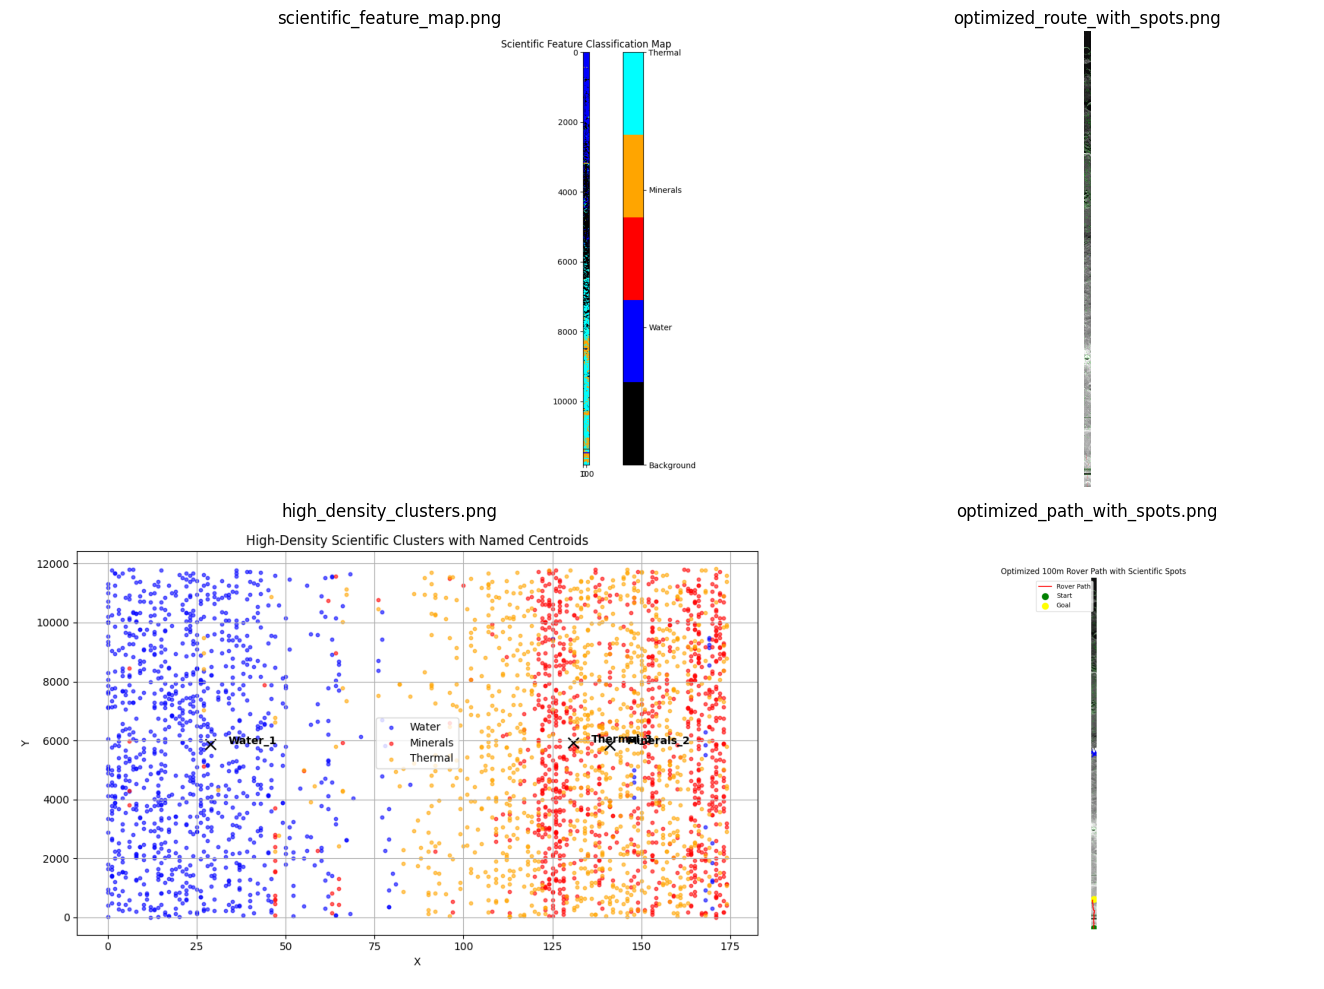

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Google Colab Code for Rover Path Planning with Scientific Spot Proximity
# Combines Hunger Games Optimization with RRT for a 100-meter path that starts and ends at specified points,
# prioritizes proximity to named scientific spots, and ensures safe navigation around craters and boulders.
# Optimized to prevent session crashes with downsampling and memory management.
# Includes visualization of all images in the results folder using Matplotlib.

# Step 1: Install required libraries
!pip install opencv-python-headless numpy matplotlib pandas geopandas shapely scikit-learn spectral fiona --quiet

# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from google.colab import files
from google.colab import drive
import random
import os
from sklearn.cluster import KMeans
from spectral.io import envi
import glob
import logging

# Set up logging to capture errors
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Step 2: Mount Google Drive for .qub file access
logging.info("Mounting Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    logging.error(f"Error mounting Google Drive: {e}")
    raise

# Step 3: Create output directory
output_dir = "/content/results/"
try:
    os.makedirs(output_dir, exist_ok=True)
    os.chmod(output_dir, 0o777)  # Ensure write permissions
except Exception as e:
    logging.error(f"Error creating output directory {output_dir}: {e}")
    raise
logging.info(f"Output directory created: {output_dir}")

# Step 4: Specify file paths for inputs
img_filename = "/content/drive/MyDrive/IIRS DATA TEST/iirs2-20250417T163757Z-001/iirs2/browse/calibrated/20221227/ch2_iir_nci_20221227T1144179457_b_brw_d32.png"
hdr_filename = "/content/drive/MyDrive/IIRS DATA TEST/iirs2-20250417T163757Z-001/iirs2/data/calibrated/20221227/ch2_iir_nci_20221227T1144179457_d_img_d32.hdr"
qub_filename = "/content/drive/MyDrive/IIRS DATA TEST/ch2_iir_nci_20221227T1144179457_d_img_d32.qub"

# Verify file existence
for fname in [img_filename, hdr_filename, qub_filename]:
    if not os.path.exists(fname):
        logging.error(f"File not found: {fname}")
        raise FileNotFoundError(f"File not found: {fname}")
logging.info("All input files found.")

# Step 5: Preprocess terrain image
logging.info("Loading terrain image...")
raster_img = cv2.imread(img_filename, cv2.IMREAD_GRAYSCALE)
if raster_img is None:
    logging.error(f"Could not load terrain image: {img_filename}")
    raise FileNotFoundError(f"Could not load terrain image: {img_filename}")
height, width = raster_img.shape
logging.info(f"Terrain image dimensions: {height}x{width}")

blurred = cv2.GaussianBlur(raster_img, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# Detect contours as obstacles (craters and boulders)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
raster_colored = cv2.cvtColor(raster_img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(raster_colored, contours, -1, (0, 255, 0), 1)

# Create obstacle mask
obstacle_mask = np.zeros_like(raster_img, dtype=np.uint8)
cv2.drawContours(obstacle_mask, contours, -1, (255), thickness=cv2.FILLED)

# Step 6: Define start and end points
pixel_to_meter = 0.1  # 1 pixel = 0.1 meters
max_path_length_pixels = 1000  # 100 meters / 0.1 m/pixel
start = (height - 10, width // 2)  # Start near bottom center
end = (max(height - max_path_length_pixels, 10), width // 2)  # End ~100 meters up
logging.info(f"Start point: {start}, End point: {end}")

# Step 7: Read and downsample hyperspectral cube data
logging.info("Loading hyperspectral cube...")
try:
    cube = envi.open(hdr_filename, qub_filename).load()
    cube = np.array(cube)  # Shape: height, width, bands
    logging.info(f"Original cube shape: {cube.shape}")

    # Downsample to match terrain image dimensions
    scale_factor = min(height / cube.shape[0], width / cube.shape[1])
    if scale_factor < 1:
        cube = cv2.resize(cube, (width, height))
        logging.info(f"Downsampled cube shape: {cube.shape}")
except Exception as e:
    logging.error(f"Error loading hyperspectral data: {e}")
    raise

# Step 8: Process hyperspectral cube for scientific feature classification
num_bands = cube.shape[2]
try:
    # Attempt to get wavelengths from .hdr metadata
    wavelengths = envi.open(hdr_filename).metadata.get('wavelength', np.linspace(0.8, 2.5, num_bands))
    wavelengths = np.array(wavelengths, dtype=float)
except:
    wavelengths = np.linspace(0.8, 2.5, num_bands)
logging.info(f"Assigned wavelengths. First 10: {wavelengths[:10]}")

# Sample a subset of pixels for clustering to reduce memory usage
logging.info("Sampling pixels for clustering...")
max_samples = 10000  # Maximum number of pixels to cluster
pixels = cube.reshape(-1, num_bands)
if pixels.shape[0] > max_samples:
    indices = np.random.choice(pixels.shape[0], max_samples, replace=False)
    X = pixels[indices]
else:
    X = pixels
logging.info(f"Sampled data shape: {X.shape}")

# Perform K-means clustering
n_clusters = 4  # Water, Minerals, Thermal, Ices
logging.info("Running K-means clustering...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_sample = kmeans.fit_predict(X)
del X  # Free memory

# Predict labels for all pixels
logging.info("Predicting labels for all pixels...")
labels = kmeans.predict(pixels)
del pixels  # Free memory
label_map = labels.reshape(height, width)
del labels  # Free memory
logging.info("Clustering completed.")

# Step 9: Create high-density cluster dataframe with named scientific spots
logging.info("Creating cluster dataframe...")
high_density_df = pd.DataFrame({
    'x': np.repeat(np.arange(width), height),
    'y': np.tile(np.arange(height), width),
    'label': label_map.flatten()
})

# Filter high-density clusters (exclude background, label 0)
high_density_df = high_density_df[high_density_df['label'].isin([1, 2, 3, 4])]

# Compute centroids and assign names
label_names = {1: "Water", 2: "Minerals", 3: "Thermal", 4: "Ices"}
centroid_coords = []
for label in [1, 2, 3, 4]:
    subset = high_density_df[high_density_df['label'] == label]
    if not subset.empty:
        centroid = [subset['x'].mean(), subset['y'].mean(), label, f"{label_names[label]}_{label}"]
        centroid_coords.append(centroid)
centroid_df = pd.DataFrame(centroid_coords, columns=["x", "y", "label", "name"])
logging.info("Scientific spots (centroids):")
logging.info(centroid_df[['name', 'x', 'y']])

# Step 10: Visualize label map
logging.info("Generating scientific feature map...")
cmap = mcolors.ListedColormap(['black', 'blue', 'red', 'orange', 'cyan'])
labels_legend = ['Background', 'Water', 'Minerals', 'Thermal', 'Ices']
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(label_map, cmap=cmap, interpolation='nearest')
cbar = plt.colorbar(im, ticks=range(5), ax=ax)
cbar.ax.set_yticklabels(labels_legend)
plt.title("Scientific Feature Classification Map")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "scientific_feature_map.png"))
plt.close()

# Step 11: Visualize clusters with named centroids
logging.info("Generating cluster visualization...")
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue', 'red', 'orange', 'cyan']
for class_id, color in zip([1, 2, 3, 4], colors):
    subset = high_density_df[high_density_df['label'] == class_id]
    if not subset.empty:
        subset = subset.sample(min(1000, len(subset)))
        ax.scatter(subset['x'], subset['y'], s=10, label=label_names[class_id], alpha=0.6, c=color)
for _, row in centroid_df.iterrows():
    ax.scatter(row['x'], row['y'], marker='x', c='black', s=100)
    ax.text(row['x'] + 5, row['y'] + 5, row['name'], fontsize=10, color='black', weight='bold')
ax.legend()
ax.set_title("High-Density Scientific Clusters with Named Centroids")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
plt.tight_layout()
cluster_png = os.path.join(output_dir, "high_density_clusters.png")
plt.savefig(cluster_png)
logging.info(f"Cluster visualization saved to: {cluster_png}")
plt.close()

# Step 12: Export for GIS use with names
logging.info("Exporting GIS files...")
wgs_crs = "EPSG:4326"
lunar_proj = "+proj=longlat +a=1737400 +b=1737400 +no_defs"
cluster_shapefile = os.path.join(output_dir, "high_density_clusters.shp")
geometry_clusters = [Point(xy) for xy in zip(high_density_df['x'], high_density_df['y'])]
gdf_clusters = gpd.GeoDataFrame(high_density_df, geometry=geometry_clusters)

try:
    gdf_clusters.set_crs(lunar_proj, inplace=True)
except Exception as e:
    logging.warning(f"Failed to set lunar CRS: {e}. Falling back to WGS84")
    gdf_clusters.set_crs(wgs_crs, inplace=True)

# Write shapefile using fiona engine
try:
    gdf_clusters.to_file(cluster_shapefile, driver='ESRI Shapefile', engine='fiona')
    logging.info(f"MiafShapefile exported: {cluster_shapefile}")
except Exception as e:
    logging.error(f"Failed to export shapefile {cluster_shapefile}: {e}")
    raise

centroid_geojson = os.path.join(output_dir, "cluster_centroids.geojson")
geometry_centroids = [Point(xy) for xy in zip(centroid_df['x'], centroid_df['y'])]
gdf_centroids = gpd.GeoDataFrame(centroid_df, geometry=geometry_centroids)

try:
    gdf_centroids.set_crs(lunar_proj, inplace=True)
except Exception as e:
    logging.warning(f"Failed to set lunar CRS for GeoJSON: {e}. Falling back to WGS84")
    gdf_centroids.set_crs(wgs_crs, inplace=True)

try:
    gdf_centroids.to_file(centroid_geojson, driver='GeoJSON', engine='fiona')
    logging.info(f"GeoJSON exported: {centroid_geojson}")
except Exception as e:
    logging.error(f"Failed to export GeoJSON {centroid_geojson}: {e}")
    raise

# Step 13: Define Node class for RRT
class Node:
    def __init__(self, pos, parent=None, path_length=0):
        self.pos = pos
        self.parent = parent
        self.path_length = path_length

# Step 14: Utility functions for RRT
def dist(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

def collision_free(pos):
    x, y = pos
    return 0 <= x < height and 0 <= y < width and obstacle_mask[int(x), int(y)] == 0

def hgs_sample(goal, best_pos, W_adaptive, centroids):
    if random.random() < W_adaptive:
        direction = np.array(goal) - np.array(best_pos)
    elif random.random() < 0.5 and len(centroids) > 0:
        centroid = random.choice(centroids)
        direction = np.array((centroid['y'], centroid['x'])) - np.array(best_pos)
    else:
        direction = np.random.uniform(-1, 1, size=2)
    direction = direction / np.linalg.norm(direction) if np.linalg.norm(direction) > 0 else direction
    sample_point = np.array(best_pos) + direction * random.randint(10, 30)
    sample_point = np.clip(sample_point, [0, 0], [height-1, width-1])
    return tuple(sample_point.astype(int))

def calculate_path_length(node):
    length = 0
    current = node
    while current.parent:
        length += dist(current.pos, current.parent.pos)
        current = current.parent
    return length

# Step 15: RRT + Hunger Games Search with path length constraint and centroid proximity
def hgs_rrt(start, end, iterations=3000, step_size=10, max_length_pixels=1000):
    tree = [Node(start, path_length=0)]
    best_node = tree[0]
    best_score = float('inf')

    logging.info("Running RRT+HGS...")
    centroids = centroid_df.to_dict('records')
    for i in range(iterations):
        W_adaptive = i / iterations
        rand_point = hgs_sample(end, best_node.pos, W_adaptive, centroids)
        nearest = min(tree, key=lambda node: dist(node.pos, rand_point))
        direction = np.array(rand_point) - np.array(nearest.pos)
        direction = direction / np.linalg.norm(direction) if np.linalg.norm(direction) > 0 else direction
        new_pos = tuple((np.array(nearest.pos) + direction * step_size).astype(int))

        if collision_free(new_pos):
            segment_length = dist(new_pos, nearest.pos)
            new_path_length = nearest.path_length + segment_length
            if new_path_length > max_length_pixels * 1.1:
                continue

            new_node = Node(new_pos, nearest, new_path_length)
            tree.append(new_node)

            goal_dist = dist(new_pos, end)
            centroid_dist = 0
            if centroids:
                distances = [dist(new_pos, (c['y'], c['x'])) for c in centroids]
                centroid_dist = min(distances) * 0.5
            score = goal_dist + centroid_dist

            if score < best_score:
                best_node = new_node
                best_score = score

            if goal_dist < 20 and abs(new_path_length - max_length_pixels) < 100:
                logging.info(f"Goal reached! Path length: {new_path_length * pixel_to_meter:.2f} meters")
                return new_node

    logging.info(f"RRT completed. Best path length: {best_node.path_length * pixel_to_meter:.2f} meters")
    return best_node

# Step 16: Execute RRT+HGS
final_node = hgs_rrt(start, end, iterations=3000, step_size=10, max_length_pixels=max_path_length_pixels)

# Step 17: Extract path and create new PNG with route and named scientific spots
logging.info("Generating path and new PNG output...")
path_coords = []
route_image = raster_colored.copy()
if final_node:
    current = final_node
    while current:
        path_coords.append(current.pos)
        current = current.parent

    for coord in path_coords:
        y, x = coord
        cv2.circle(route_image, (x, y), 2, (0, 0, 255), -1)

    for _, row in centroid_df.iterrows():
        x, y = int(row['x']), int(row['y'])
        cv2.circle(route_image, (x, y), 5, (255, 0, 0), -1)
        cv2.putText(route_image, row['name'], (x + 5, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# Save the new PNG output
route_output_filename = "optimized_route_with_spots.png"
cv2.imwrite(os.path.join(output_dir, route_output_filename), route_image)
logging.info(f"New route PNG saved to: {os.path.join(output_dir, route_output_filename)}")

# Step 18: Visualize path on original image for matplotlib output
for coord in path_coords:
    y, x = coord
    cv2.circle(raster_colored, (x, y), 2, (0, 0, 255), -1)

for _, row in centroid_df.iterrows():
    x, y = int(row['x']), int(row['y'])
    cv2.circle(raster_colored, (x, y), 5, (255, 0, 0), -1)

# Step 19: Display results with matplotlib
logging.info("Generating matplotlib visualization...")
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(raster_colored, cv2.COLOR_BGR2RGB))
for _, row in centroid_df.iterrows():
    plt.scatter(row['x'], row['y'], c='blue', marker='x', s=100)
    plt.text(row['x'] + 5, row['y'] + 5, row['name'], fontsize=10, color='white', weight='bold')
plt.plot([x for _, x in path_coords], [y for y, _ in path_coords], 'r-', label='Rover Path')
plt.scatter([start[1]], [start[0]], c='green', marker='o', s=100, label='Start')
plt.scatter([end[1]], [end[0]], c='yellow', marker='o', s=100, label='Goal')
plt.legend()
plt.axis("off")
plt.title("Optimized 100m Rover Path with Scientific Spots")
plt.savefig(os.path.join(output_dir, "optimized_path_with_spots.png"))
plt.close()

# Step 20: Visualize all images in the results folder
logging.info("Displaying all images in the results folder...")
image_files = glob.glob(os.path.join(output_dir, "*.png"))
if not image_files:
    logging.warning("No PNG images found in the results folder.")
else:
    num_images = len(image_files)
    cols = 2
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    if num_images == 1:
        axes = np.array([[axes]])
    elif num_images < rows * cols:
        axes = axes.flatten()
    for idx, img_path in enumerate(image_files):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = axes[idx // cols, idx % cols] if num_images > 1 else axes[0, 0]
        ax.imshow(img)
        ax.set_title(os.path.basename(img_path))
        ax.axis('off')
    for idx in range(len(image_files), rows * cols):
        ax = axes[idx // cols, idx % cols] if num_images > 1 else axes[0, 0]
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    logging.info(f"Displayed {num_images} images from the results folder.")

# Step 21: Save and download outputs
logging.info("Saving and downloading outputs...")
cv2.imwrite(os.path.join(output_dir, "optimized_path_with_spots.png"), raster_colored)
files.download(os.path.join(output_dir, "optimized_path_with_spots.png"))
files.download(os.path.join(output_dir, route_output_filename))
files.download(cluster_shapefile)
files.download(centroid_geojson)
logging.info("Execution completed.")

ARROUND SPOTS

Mounted at /content/drive


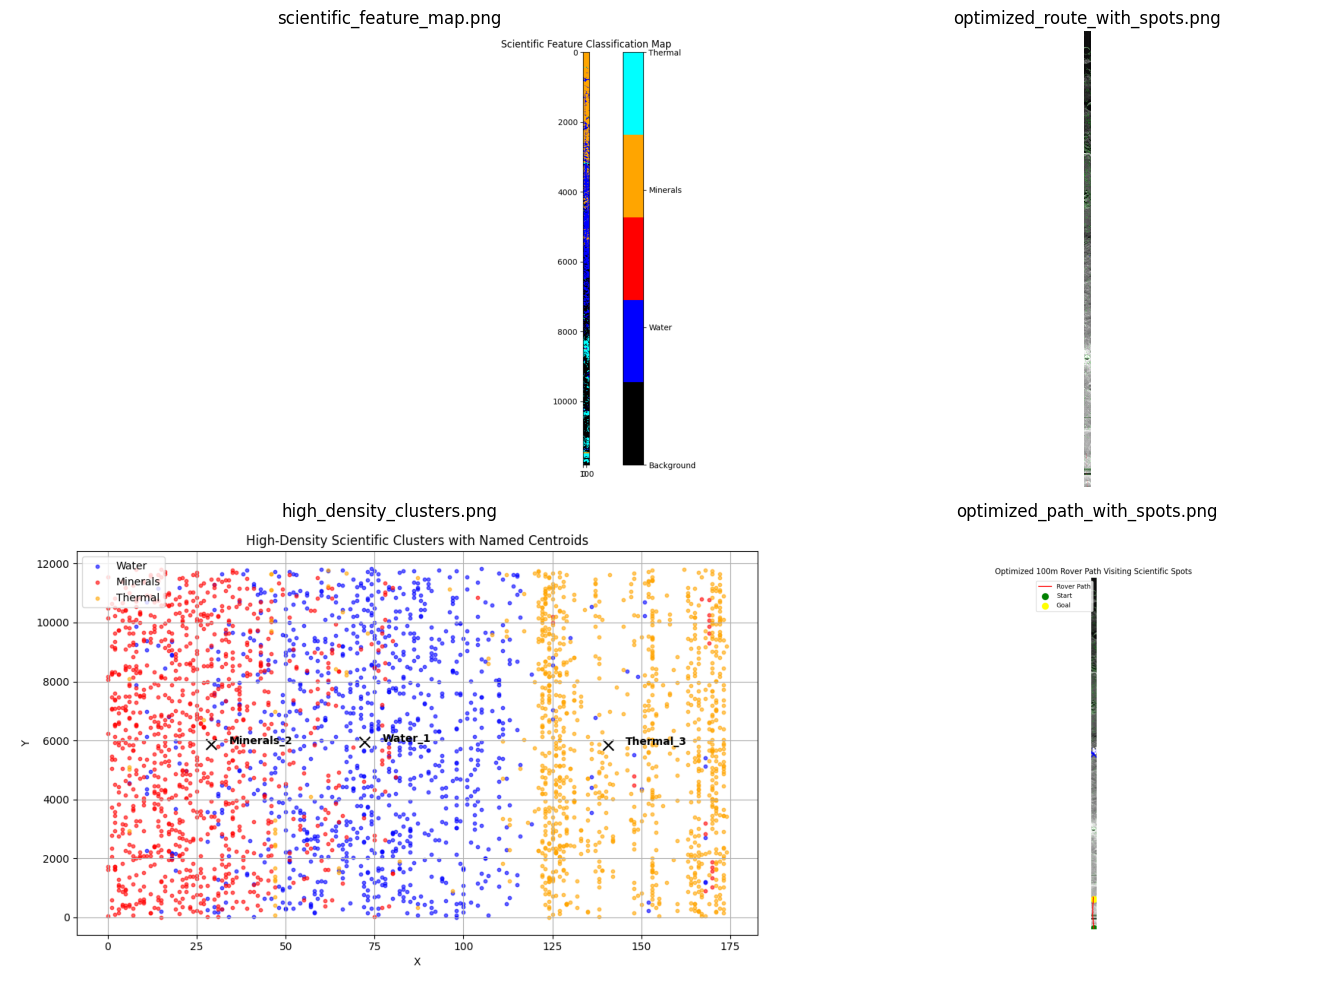

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Google Colab Code for Rover Path Planning with Scientific Spot Proximity
# Combines Hunger Games Optimization with RRT for a 100-meter path that starts and ends at specified points,
# prioritizes visiting named scientific spots, and ensures safe navigation around craters and boulders.
# Optimized to prevent session crashes with downsampling and memory management.
# Includes visualization of all images in the results folder using Matplotlib.

# Step 1: Install required libraries
!pip install opencv-python-headless numpy matplotlib pandas geopandas shapely scikit-learn spectral fiona --quiet

# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from google.colab import files
from google.colab import drive
import random
import os
from sklearn.cluster import KMeans
from spectral.io import envi
import glob
import logging

# Set up logging to capture errors
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Step 2: Mount Google Drive for .qub file access
logging.info("Mounting Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    logging.error(f"Error mounting Google Drive: {e}")
    raise

# Step 3: Create output directory
output_dir = "/content/results/"
try:
    os.makedirs(output_dir, exist_ok=True)
    os.chmod(output_dir, 0o777)  # Ensure write permissions
except Exception as e:
    logging.error(f"Error creating output directory {output_dir}: {e}")
    raise
logging.info(f"Output directory created: {output_dir}")

# Step 4: Specify file paths for inputs
img_filename = "/content/drive/MyDrive/IIRS DATA TEST/iirs2-20250417T163757Z-001/iirs2/browse/calibrated/20221227/ch2_iir_nci_20221227T1144179457_b_brw_d32.png"
hdr_filename = "/content/drive/MyDrive/IIRS DATA TEST/iirs2-20250417T163757Z-001/iirs2/data/calibrated/20221227/ch2_iir_nci_20221227T1144179457_d_img_d32.hdr"
qub_filename = "/content/drive/MyDrive/IIRS DATA TEST/ch2_iir_nci_20221227T1144179457_d_img_d32.qub"

# Verify file existence
for fname in [img_filename, hdr_filename, qub_filename]:
    if not os.path.exists(fname):
        logging.error(f"File not found: {fname}")
        raise FileNotFoundError(f"File not found: {fname}")
logging.info("All input files found.")

# Step 5: Preprocess terrain image
logging.info("Loading terrain image...")
raster_img = cv2.imread(img_filename, cv2.IMREAD_GRAYSCALE)
if raster_img is None:
    logging.error(f"Could not load terrain image: {img_filename}")
    raise FileNotFoundError(f"Could not load terrain image: {img_filename}")
height, width = raster_img.shape
logging.info(f"Terrain image dimensions: {height}x{width}")

blurred = cv2.GaussianBlur(raster_img, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# Detect contours as obstacles (craters and boulders)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
raster_colored = cv2.cvtColor(raster_img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(raster_colored, contours, -1, (0, 255, 0), 1)

# Create obstacle mask
obstacle_mask = np.zeros_like(raster_img, dtype=np.uint8)
cv2.drawContours(obstacle_mask, contours, -1, (255), thickness=cv2.FILLED)

# Step 6: Define start and end points
pixel_to_meter = 0.1  # 1 pixel = 0.1 meters
max_path_length_pixels = 1000  # 100 meters / 0.1 m/pixel
start = (height - 10, width // 2)  # Start near bottom center
end = (max(height - max_path_length_pixels, 10), width // 2)  # End ~100 meters up
logging.info(f"Start point: {start}, End point: {end}")

# Step 7: Read and downsample hyperspectral cube data
logging.info("Loading hyperspectral cube...")
try:
    cube = envi.open(hdr_filename, qub_filename).load()
    cube = np.array(cube)  # Shape: height, width, bands
    logging.info(f"Original cube shape: {cube.shape}")

    # Downsample to match terrain image dimensions
    scale_factor = min(height / cube.shape[0], width / cube.shape[1])
    if scale_factor < 1:
        cube = cv2.resize(cube, (width, height))
        logging.info(f"Downsampled cube shape: {cube.shape}")
except Exception as e:
    logging.error(f"Error loading hyperspectral data: {e}")
    raise

# Step 8: Process hyperspectral cube for scientific feature classification
num_bands = cube.shape[2]
try:
    # Attempt to get wavelengths from .hdr metadata
    wavelengths = envi.open(hdr_filename).metadata.get('wavelength', np.linspace(0.8, 2.5, num_bands))
    wavelengths = np.array(wavelengths, dtype=float)
except:
    wavelengths = np.linspace(0.8, 2.5, num_bands)
logging.info(f"Assigned wavelengths. First 10: {wavelengths[:10]}")

# Sample a subset of pixels for clustering to reduce memory usage
logging.info("Sampling pixels for clustering...")
max_samples = 10000  # Maximum number of pixels to cluster
pixels = cube.reshape(-1, num_bands)
if pixels.shape[0] > max_samples:
    indices = np.random.choice(pixels.shape[0], max_samples, replace=False)
    X = pixels[indices]
else:
    X = pixels
logging.info(f"Sampled data shape: {X.shape}")

# Perform K-means clustering
n_clusters = 4  # Water, Minerals, Thermal, Ices
logging.info("Running K-means clustering...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_sample = kmeans.fit_predict(X)
del X  # Free memory

# Predict labels for all pixels
logging.info("Predicting labels for all pixels...")
labels = kmeans.predict(pixels)
del pixels  # Free memory
label_map = labels.reshape(height, width)
del labels  # Free memory
logging.info("Clustering completed.")

# Step 9: Create high-density cluster dataframe with named scientific spots
logging.info("Creating cluster dataframe...")
high_density_df = pd.DataFrame({
    'x': np.repeat(np.arange(width), height),
    'y': np.tile(np.arange(height), width),
    'label': label_map.flatten()
})

# Filter high-density clusters (exclude background, label 0)
high_density_df = high_density_df[high_density_df['label'].isin([1, 2, 3, 4])]

# Compute centroids and assign names
label_names = {1: "Water", 2: "Minerals", 3: "Thermal", 4: "Ices"}
centroid_coords = []
for label in [1, 2, 3, 4]:
    subset = high_density_df[high_density_df['label'] == label]
    if not subset.empty:
        centroid = [subset['x'].mean(), subset['y'].mean(), label, f"{label_names[label]}_{label}"]
        centroid_coords.append(centroid)
centroid_df = pd.DataFrame(centroid_coords, columns=["x", "y", "label", "name"])
logging.info("Scientific spots (centroids):")
logging.info(centroid_df[['name', 'x', 'y']])

# Step 10: Visualize label map
logging.info("Generating scientific feature map...")
cmap = mcolors.ListedColormap(['black', 'blue', 'red', 'orange', 'cyan'])
labels_legend = ['Background', 'Water', 'Minerals', 'Thermal', 'Ices']
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(label_map, cmap=cmap, interpolation='nearest')
cbar = plt.colorbar(im, ticks=range(5), ax=ax)
cbar.ax.set_yticklabels(labels_legend)
plt.title("Scientific Feature Classification Map")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "scientific_feature_map.png"))
plt.close()

# Step 11: Visualize clusters with named centroids
logging.info("Generating cluster visualization...")
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue', 'red', 'orange', 'cyan']
for class_id, color in zip([1, 2, 3, 4], colors):
    subset = high_density_df[high_density_df['label'] == class_id]
    if not subset.empty:
        subset = subset.sample(min(1000, len(subset)))
        ax.scatter(subset['x'], subset['y'], s=10, label=label_names[class_id], alpha=0.6, c=color)
for _, row in centroid_df.iterrows():
    ax.scatter(row['x'], row['y'], marker='x', c='black', s=100)
    ax.text(row['x'] + 5, row['y'] + 5, row['name'], fontsize=10, color='black', weight='bold')
ax.legend()
ax.set_title("High-Density Scientific Clusters with Named Centroids")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
plt.tight_layout()
cluster_png = os.path.join(output_dir, "high_density_clusters.png")
plt.savefig(cluster_png)
logging.info(f"Cluster visualization saved to: {cluster_png}")
plt.close()

# Step 12: Export for GIS use with names
logging.info("Exporting GIS files...")
wgs_crs = "EPSG:4326"
lunar_proj = "+proj=longlat +a=1737400 +b=1737400 +no_defs"
cluster_shapefile = os.path.join(output_dir, "high_density_clusters.shp")
geometry_clusters = [Point(xy) for xy in zip(high_density_df['x'], high_density_df['y'])]
gdf_clusters = gpd.GeoDataFrame(high_density_df, geometry=geometry_clusters)

try:
    gdf_clusters.set_crs(lunar_proj, inplace=True)
except Exception as e:
    logging.warning(f"Failed to set lunar CRS: {e}. Falling back to WGS84")
    gdf_clusters.set_crs(wgs_crs, inplace=True)

# Write shapefile using fiona engine
try:
    gdf_clusters.to_file(cluster_shapefile, driver='ESRI Shapefile', engine='fiona')
    logging.info(f"Shapefile exported: {cluster_shapefile}")
except Exception as e:
    logging.error(f"Failed to export shapefile {cluster_shapefile}: {e}")
    raise

centroid_geojson = os.path.join(output_dir, "cluster_centroids.geojson")
geometry_centroids = [Point(xy) for xy in zip(centroid_df['x'], centroid_df['y'])]
gdf_centroids = gpd.GeoDataFrame(centroid_df, geometry=geometry_centroids)

try:
    gdf_centroids.set_crs(lunar_proj, inplace=True)
except Exception as e:
    logging.warning(f"Failed to set lunar CRS for GeoJSON: {e}. Falling back to WGS84")
    gdf_centroids.set_crs(wgs_crs, inplace=True)

try:
    gdf_centroids.to_file(centroid_geojson, driver='GeoJSON', engine='fiona')
    logging.info(f"GeoJSON exported: {centroid_geojson}")
except Exception as e:
    logging.error(f"Failed to export GeoJSON {centroid_geojson}: {e}")
    raise

# Step 13: Define Node class for RRT
class Node:
    def __init__(self, pos, parent=None, path_length=0):
        self.pos = pos
        self.parent = parent
        self.path_length = path_length

# Step 14: Utility functions for RRT
def dist(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

def collision_free(pos):
    x, y = pos
    return 0 <= x < height and 0 <= y < width and obstacle_mask[int(x), int(y)] == 0

def hgs_sample(goal, best_pos, W_adaptive, centroids):
    # Increase probability of sampling near centroids to ensure path visits them
    if random.random() < 0.7 and len(centroids) > 0:  # 70% chance to sample near a centroid
        centroid = random.choice(centroids)
        direction = np.array((centroid['y'], centroid['x'])) - np.array(best_pos)
    elif random.random() < W_adaptive:  # Sample toward goal with adaptive weight
        direction = np.array(goal) - np.array(best_pos)
    else:  # Random sampling
        direction = np.random.uniform(-1, 1, size=2)
    direction = direction / np.linalg.norm(direction) if np.linalg.norm(direction) > 0 else direction
    sample_point = np.array(best_pos) + direction * random.randint(10, 30)
    sample_point = np.clip(sample_point, [0, 0], [height-1, width-1])
    return tuple(sample_point.astype(int))

def calculate_path_length(node):
    length = 0
    current = node
    while current.parent:
        length += dist(current.pos, current.parent.pos)
        current = current.parent
    return length

# Step 15: RRT + Hunger Games Search with path length constraint and centroid proximity
def hgs_rrt(start, end, iterations=5000, step_size=10, max_length_pixels=1000):
    tree = [Node(start, path_length=0)]
    best_node = tree[0]
    best_score = float('inf')
    proximity_threshold = 20  # Pixels; path must pass within this distance of centroids

    logging.info("Running RRT+HGS with centroid proximity...")
    centroids = centroid_df.to_dict('records')
    for i in range(iterations):
        W_adaptive = i / iterations
        rand_point = hgs_sample(end, best_node.pos, W_adaptive, centroids)
        nearest = min(tree, key=lambda node: dist(node.pos, rand_point))
        direction = np.array(rand_point) - np.array(nearest.pos)
        direction = direction / np.linalg.norm(direction) if np.linalg.norm(direction) > 0 else direction
        new_pos = tuple((np.array(nearest.pos) + direction * step_size).astype(int))

        if collision_free(new_pos):
            segment_length = dist(new_pos, nearest.pos)
            new_path_length = nearest.path_length + segment_length
            if new_path_length > max_length_pixels * 1.1:  # Allow 10% overrun
                continue

            new_node = Node(new_pos, nearest, new_path_length)
            tree.append(new_node)

            # Calculate score: prioritize proximity to centroids, then goal
            goal_dist = dist(new_pos, end)
            centroid_dists = [dist(new_pos, (c['y'], c['x'])) for c in centroids] if centroids else [0]
            min_centroid_dist = min(centroid_dists) if centroid_dists else 0
            # Heavily weight centroid proximity
            score = goal_dist + min_centroid_dist * 2  # Increase centroid influence

            # Check if path is close to centroids
            visited_centroids = sum(1 for d in centroid_dists if d < proximity_threshold)
            if visited_centroids > 0:  # Bonus for visiting centroids
                score -= visited_centroids * 50  # Reduce score to favor paths near centroids

            if score < best_score:
                best_node = new_node
                best_score = score

            # Early termination if goal is reached and path is near at least one centroid
            if goal_dist < 20 and abs(new_path_length - max_length_pixels) < 100 and visited_centroids > 0:
                logging.info(f"Goal reached! Path length: {new_path_length * pixel_to_meter:.2f} meters, Visited {visited_centroids} centroids")
                return new_node

    # Log best path details
    final_centroid_dists = [dist(best_node.pos, (c['y'], c['x'])) for c in centroids] if centroids else [0]
    visited_centroids = sum(1 for d in final_centroid_dists if d < proximity_threshold)
    logging.info(f"RRT completed. Best path length: {best_node.path_length * pixel_to_meter:.2f} meters, Visited {visited_centroids} centroids")
    return best_node

# Step 16: Execute RRT+HGS
final_node = hgs_rrt(start, end, iterations=5000, step_size=10, max_length_pixels=max_path_length_pixels)

# Step 17: Extract path and create new PNG with route and named scientific spots
logging.info("Generating path and new PNG output...")
path_coords = []
route_image = raster_colored.copy()
if final_node:
    current = final_node
    while current:
        path_coords.append(current.pos)
        current = current.parent

    for coord in path_coords:
        y, x = coord
        cv2.circle(route_image, (x, y), 2, (0, 0, 255), -1)

    for _, row in centroid_df.iterrows():
        x, y = int(row['x']), int(row['y'])
        cv2.circle(route_image, (x, y), 5, (255, 0, 0), -1)
        cv2.putText(route_image, row['name'], (x + 5, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# Save the new PNG output
route_output_filename = "optimized_route_with_spots.png"
cv2.imwrite(os.path.join(output_dir, route_output_filename), route_image)
logging.info(f"New route PNG saved to: {os.path.join(output_dir, route_output_filename)}")

# Step 18: Visualize path on original image for matplotlib output
for coord in path_coords:
    y, x = coord
    cv2.circle(raster_colored, (x, y), 2, (0, 0, 255), -1)

for _, row in centroid_df.iterrows():
    x, y = int(row['x']), int(row['y'])
    cv2.circle(raster_colored, (x, y), 5, (255, 0, 0), -1)

# Step 19: Display results with matplotlib
logging.info("Generating matplotlib visualization...")
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(raster_colored, cv2.COLOR_BGR2RGB))
for _, row in centroid_df.iterrows():
    plt.scatter(row['x'], row['y'], c='blue', marker='x', s=100)
    plt.text(row['x'] + 5, row['y'] + 5, row['name'], fontsize=10, color='white', weight='bold')
plt.plot([x for _, x in path_coords], [y for y, _ in path_coords], 'r-', label='Rover Path')
plt.scatter([start[1]], [start[0]], c='green', marker='o', s=100, label='Start')
plt.scatter([end[1]], [end[0]], c='yellow', marker='o', s=100, label='Goal')
plt.legend()
plt.axis("off")
plt.title("Optimized 100m Rover Path Visiting Scientific Spots")
plt.savefig(os.path.join(output_dir, "optimized_path_with_spots.png"))
plt.close()

# Step 20: Visualize all images in the results folder
logging.info("Displaying all images in the results folder...")
image_files = glob.glob(os.path.join(output_dir, "*.png"))
if not image_files:
    logging.warning("No PNG images found in the results folder.")
else:
    num_images = len(image_files)
    cols = 2
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    if num_images == 1:
        axes = np.array([[axes]])
    elif num_images < rows * cols:
        axes = axes.flatten()
    for idx, img_path in enumerate(image_files):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = axes[idx // cols, idx % cols] if num_images > 1 else axes[0, 0]
        ax.imshow(img)
        ax.set_title(os.path.basename(img_path))
        ax.axis('off')
    for idx in range(len(image_files), rows * cols):
        ax = axes[idx // cols, idx % cols] if num_images > 1 else axes[0, 0]
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    logging.info(f"Displayed {num_images} images from the results folder.")

# Step 21: Save and download outputs
logging.info("Saving and downloading outputs...")
cv2.imwrite(os.path.join(output_dir, "optimized_path_with_spots.png"), raster_colored)
files.download(os.path.join(output_dir, "optimized_path_with_spots.png"))
files.download(os.path.join(output_dir, route_output_filename))
files.download(cluster_shapefile)
files.download(centroid_geojson)
logging.info("Execution completed.")